## ANALYZE DATA FOR QUESTION 5 AND 6

## IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ cho đẹp
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## READ DATA

In [10]:
df = pd.read_csv('../../data/student_academic_performance_1M.csv')

df.head()

,math_score,science_score,english_score,history_score,computer_score,attendance_rate,assignment_avg,quiz_avg,project_score,previous_gpa,...,final_gpa,standardized_exam_score,improvement_next_term,dropout_risk_score,learning_efficiency,stress_index,pass_fail,honors_flag,at_risk_flag,top_performer_flag
0,62.456370,88.073740,72.526180,76.06144,92.64728,1.000000,104.827740,68.451580,81.24903,2.890757,...,4.000000,78.581310,2.040133,0.001787,-1.235061,5.918975,1,0,0,0
1,56.778812,65.597540,69.882500,69.57163,71.62665,0.729115,51.119255,80.345620,81.51603,2.693535,...,2.910472,52.727460,-1.696975,0.679032,1.416623,6.216345,1,0,1,0
2,78.238100,69.305824,76.588830,75.70467,67.68652,0.634656,47.222202,72.382280,58.76614,2.721305,...,2.412240,73.162010,-1.354060,0.756908,0.684399,5.116631,1,0,1,0
3,86.619550,81.867950,87.423485,76.50009,86.60630,0.811508,69.160630,63.451378,49.04596,3.366405,...,3.244543,85.844340,1.749234,0.962086,-1.249343,3.829115,1,0,1,0
4,65.569824,76.941990,67.950760,67.18360,73.40711,0.786856,44.262510,64.553490,48.36373,2.618776,...,2.294958,56.980495,-0.747696,0.698020,-1.555532,4.509945,1,0,1,0


## Question 5: Liệu một sinh viên có gia đình giàu có và học thức cao ảnh hưởng thế nào đến tâm lý của họ?

### 5.1 Kiểm tra phân phối của đặc trưng thể hiện độ học thức của gia đình `parent_education`

In [9]:
print(df['parent_education'].value_counts())

parent_education
3.0    167143
5.0    166724
0.0    166688
2.0    166660
1.0    166473
4.0    166312
Name: count, dtype: int64


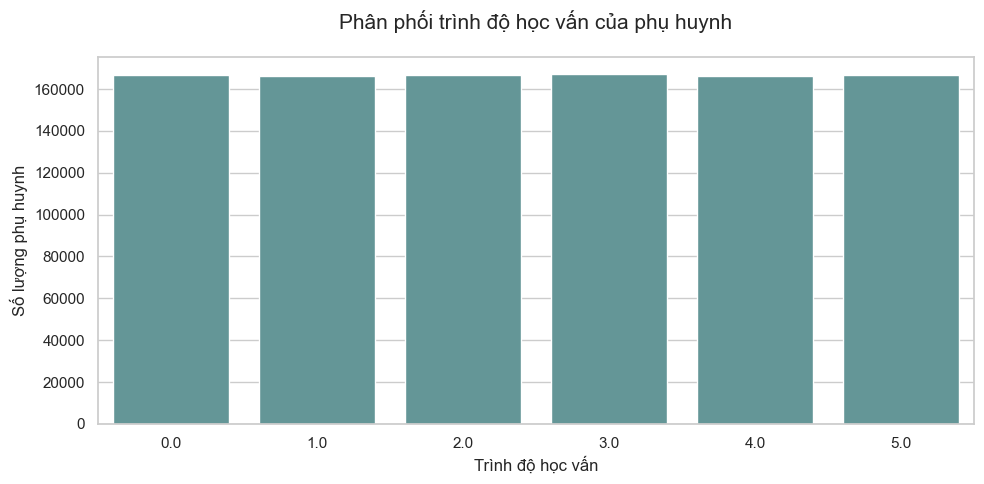

In [19]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df, 
    x='parent_education',
    color = '#5b9ea0'
)

plt.title('Phân phối trình độ học vấn của phụ huynh', fontsize=15, pad=20)
plt.xlabel('Trình độ học vấn', fontsize=12)
plt.ylabel('Số lượng phụ huynh', fontsize=12)

plt.tight_layout()
plt.show()

- Phân phối đều: Tập dữ liệu thể hiện một sự phân bố đồng đều lý tưởng giữa các cấp bậc học vấn của phụ huynh. Điều này cho thấy mẫu khảo sát không bị lệch về phía nhóm có học vấn cao hay thấp.
- Cân bằng: Mỗi nhóm học vấn (từ mức 0 đến mức 5) đều có số lượng quan sát tương đương nhau (xấp xỉ 160.000 mẫu).
- Loại bỏ sai số do số lượng: Kết luận của bạn sẽ khách quan hơn. Bạn không sợ kết quả bị nhiễu bởi việc "do nhóm học vấn 4 có quá nhiều người nên Stress cao hơn".
- Độ tin cậy cao: Kết quả so sánh Stress giữa các nhóm sẽ có trọng số ngang nhau, giúp các phát hiện về mối quan hệ giữa parent_education và mental_stress trở nên đáng tin cậy về mặt thống kê.

### 5.2  Kiểm tra phân phối thu nhập của gia đình `family_income`

In [23]:
print(df['family_income'].value_counts())

family_income
0.150122    4
0.316358    4
0.153278    4
0.333016    4
0.294098    4
           ..
0.232556    1
0.261722    1
0.277978    1
0.407589    1
0.174693    1
Name: count, Length: 976137, dtype: int64


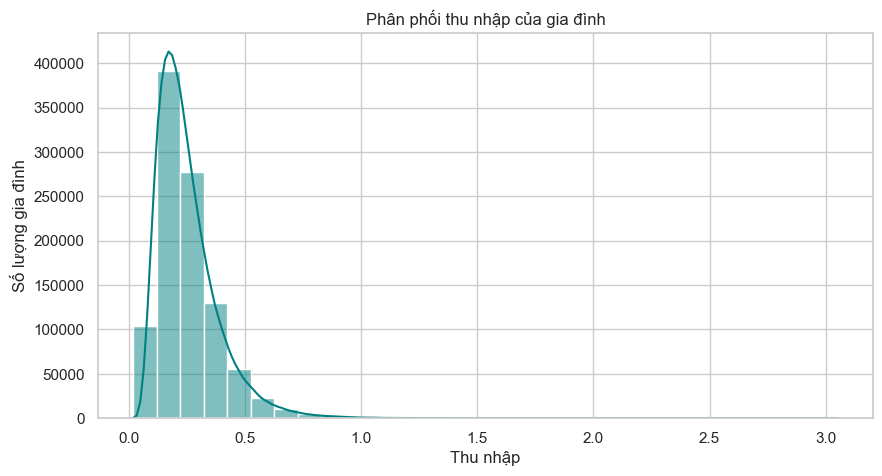

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='family_income', bins=30, kde=True, color='teal')
plt.title('Phân phối thu nhập của gia đình')
plt.xlabel('Thu nhập')
plt.ylabel('Số lượng gia đình')
plt.show()

C:\Users\ROG\AppData\Local\Temp\ipykernel_30592\668360628.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


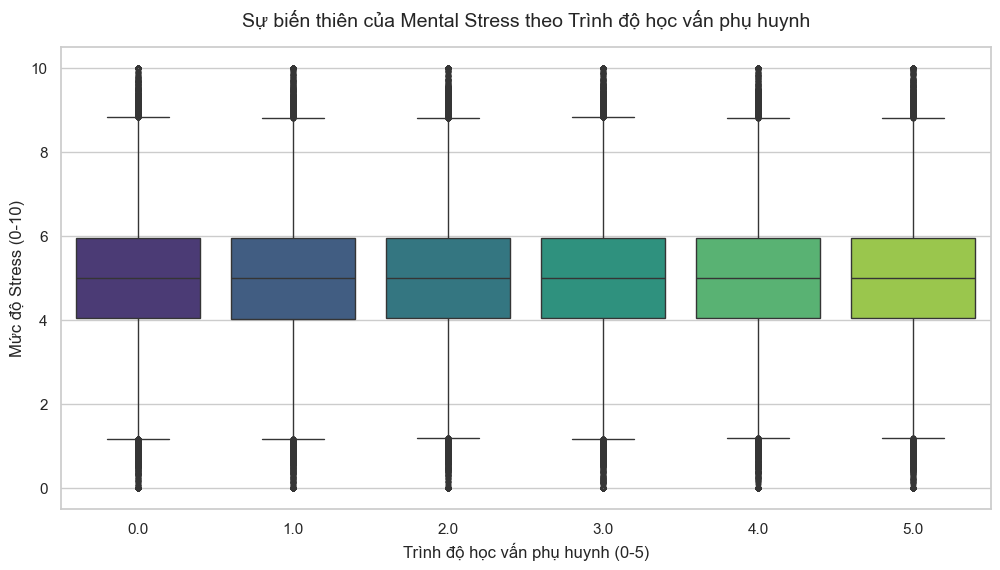

In [25]:
# Thiết lập style đồng nhất với các biểu đồ trước
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Vẽ Boxplot cho parent_education
sns.boxplot(
    data=df, 
    x='parent_education', 
    y='mental_stress', 
    palette='viridis', # Hoặc dùng color='#5b9ea0' nếu muốn 1 màu
    fliersize=3        # Kích thước các điểm dị biệt
)

plt.title('Sự biến thiên của Mental Stress theo Trình độ học vấn phụ huynh', fontsize=14, pad=15)
plt.xlabel('Trình độ học vấn phụ huynh (0-5)', fontsize=12)
plt.ylabel('Mức độ Stress (0-10)', fontsize=12)

plt.show()

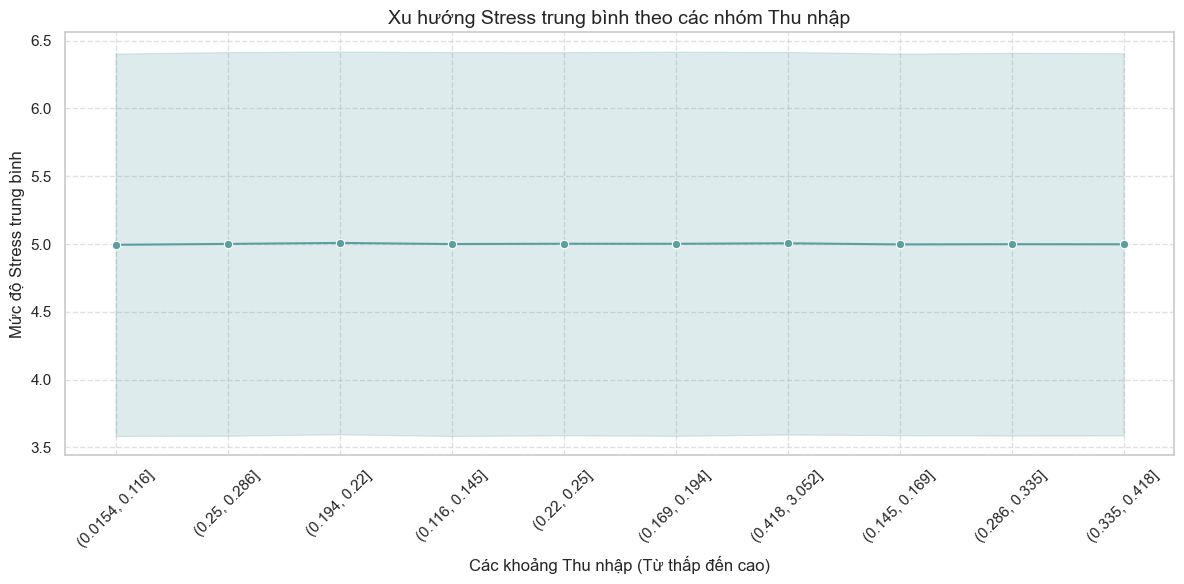

In [36]:
# 1. Chia thu nhập thành 10 nhóm (Deciles)
df['income_bins'] = pd.qcut(df['family_income'], q=10)

# 2. CHỈNH SỬA QUAN TRỌNG: Chuyển khoảng Interval thành chuỗi để Seaborn vẽ được
df['income_bins_str'] = df['income_bins'].astype(str)

plt.figure(figsize=(12, 6))

# 3. Vẽ lineplot (Seaborn sẽ tự tính toán giá trị trung bình Stress cho mỗi nhóm)
sns.lineplot(
    data=df, 
    x='income_bins_str', 
    y='mental_stress', 
    marker='o', 
    color='#5b9ea0',
    errorbar='sd' # Hiển thị dải lệch chuẩn để thấy độ biến thiên
)

plt.xticks(rotation=45)
plt.title('Xu hướng Stress trung bình theo các nhóm Thu nhập', fontsize=14)
plt.xlabel('Các khoảng Thu nhập (Từ thấp đến cao)')
plt.ylabel('Mức độ Stress trung bình')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Question 6: Sự khác biệt kết quả giữa nhóm học sinh "Học ở nhà"và "Học thêm"?

### 6.1 Kiểm tra phân phối nhóm học sinh học ở nhà và học thêm

C:\Users\ROG\AppData\Local\Temp\ipykernel_30592\620446653.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='private_tuition', data=df, palette=['#95a5a6', '#3498db'])


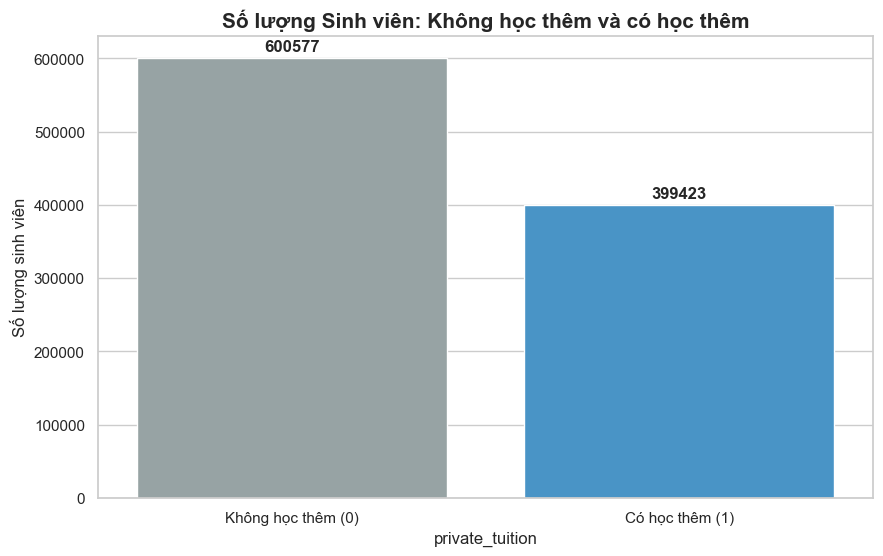

In [38]:
ax = sns.countplot(x='private_tuition', data=df, palette=['#95a5a6', '#3498db'])

# Trang trí tiêu đề và nhãn
plt.title('Số lượng Sinh viên: Không học thêm và có học thêm', fontsize=15, fontweight='bold')
plt.ylabel('Số lượng sinh viên', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Không học thêm (0)', 'Có học thêm (1)'])

# Thêm con số cụ thể trên đầu cột (Data Labels)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.show()